# Optimal channel networks with PyOCN

An **optimal channel network (OCN)** is a river network on a grid. Every cell drains to exactly
one of its 8 neighbors, so the whole network is a spanning tree pointing at an outlet. PyOCN finds
a low-energy tree by **simulated annealing**: it repeatedly reroutes one random cell and keeps the
change if it lowers the energy (or, early on, sometimes even if it does not).

The energy is $E = \sum_k A_k^\gamma$, where $A_k$ is the **drained area** of cell $k$ (how many
cells drain through it) and $\gamma \approx 0.5$. Minimizing it reproduces the scaling laws of
real rivers.

PyOCN is discrete: the state is a grid of cells, not a continuous surface. Elevation is derived
afterward from the tree.

This notebook covers:

1. Fitting one OCN and looking at its rasters.
2. Reading it as a graph, including as a per-cell parent array.
3. How fit time scales with grid size.
4. A chunked prototype: rivers that agree across chunk borders, with each chunk generated alone.
5. Whether this is a good target for the seeded PA VAE.

In [1]:
import time

import matplotlib as mpl
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import PyOCN as po

from ocn import ChunkedWorld, DIRECTIONS, area_exceedance, fit_ocn, flow_directions, rasters, time_fit

AREA_NORM = mpl.colors.PowerNorm(gamma=0.4)


def draw_flow(ax, directions, length=0.8, color="#333"):
    # One arrow per cell, from its center toward its downstream neighbor.
    for (r, c), d in np.ndenumerate(directions):
        if d >= 0:
            dr, dc = DIRECTIONS[d] * length
            ax.annotate("", xy=(c + dc, r + dr), xytext=(c, r),
                        arrowprops=dict(arrowstyle="-|>", lw=0.8, color=color, mutation_scale=7))

## 1. Fit one OCN

`from_net_type("V", ...)` starts from a simple V-shaped tree with one outlet on the border.
`fit()` uses PyOCN's default cooling schedule, which runs about $40 \times$ rows $\times$ cols
iterations.

64x64 fit in 0.65s, energy 11827.7, roots 1


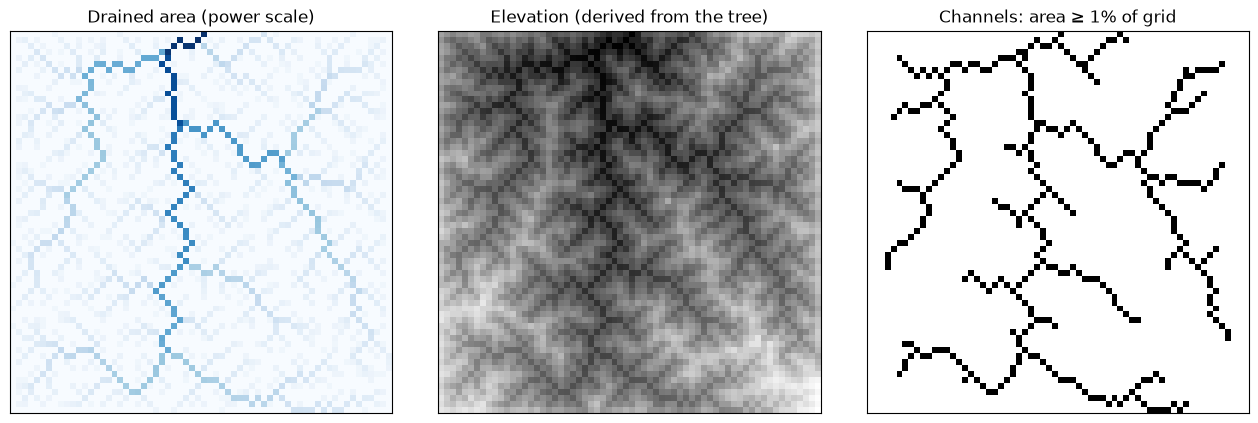

In [2]:
SIZE = 64
start = time.perf_counter()
ocn = fit_ocn(SIZE, seed=8472)
print(f"{SIZE}x{SIZE} fit in {time.perf_counter() - start:.2f}s, energy {ocn.energy:.1f}, roots {ocn.nroots}")

grids = rasters(ocn)
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
axes[0].imshow(grids["drained_area"], cmap="Blues", norm=AREA_NORM)
axes[0].set_title("Drained area (power scale)")
axes[1].imshow(grids["elevation"], cmap="Greys_r")
axes[1].set_title("Elevation (derived from the tree)")
axes[2].imshow(grids["drained_area"] >= 0.01 * SIZE * SIZE, cmap="Greys")
axes[2].set_title("Channels: area ≥ 1% of grid")
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()

The annealing history is stored on the object. Energy drops fast, then flattens as the
temperature cools.

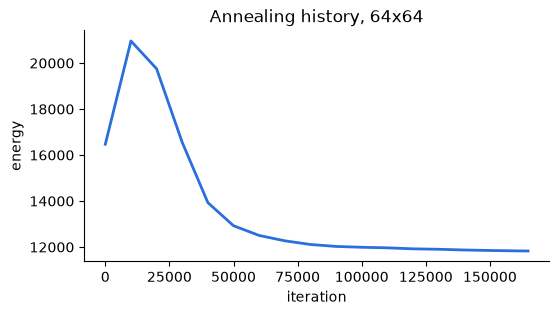

In [3]:
history = ocn.history  # columns: iteration, energy, temperature
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(history[:, 0], history[:, 1], lw=2, color="#2a6fdb")
ax.set_xlabel("iteration"); ax.set_ylabel("energy")
ax.set_title(f"Annealing history, {SIZE}x{SIZE}")
ax.spines[["top", "right"]].set_visible(False)

## 2. The OCN as a graph

`to_digraph()` returns a NetworkX DAG. Nodes are cells, and each edge points downstream. Each node
has `pos`, `drained_area`, `energy`, and `elevation`.

In [4]:
dag = ocn.to_digraph()
roots = [n for n in dag if dag.out_degree(n) == 0]
print("nodes", dag.number_of_nodes(), "edges", dag.number_of_edges())
print("is a tree pointing at one root:", nx.is_tree(dag.to_undirected()) and len(roots) == 1)
print("max in-degree (tributaries joining one cell):", max(d for _, d in dag.in_degree()))
print("example node:", next(iter(dag.nodes(data=True))))

nodes 4096 edges 4095


is a tree pointing at one root: True
max in-degree (tributaries joining one cell): 7
example node: (0, {'pos': (0, 0), 'drained_area': 1.0, '_adown': 65, '_edges': 8, '_downstream': 3, '_visited': 0, 'elevation': 4.930919666134563, 'energy': 1.0})


### As a parent array

This is the link to the seeded PA VAE. The PA tree there is a parent array:
`parent(seed, node) -> older node`. An OCN is also a parent array, but over grid cells:
`parent(seed, cell) -> one of 8 neighbor directions`. The answer set is tiny and local.
The constraint is global: the arrows must form one acyclic tree with no crossing diagonals.

direction entropy: 2.97 bits of a possible 3.00


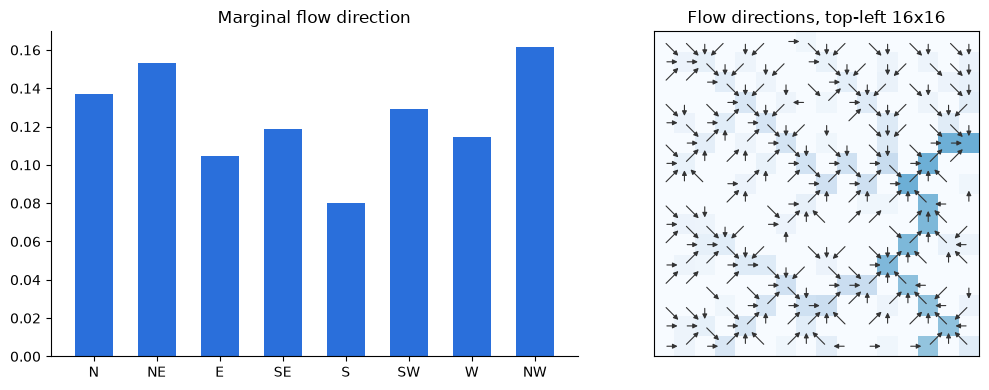

In [5]:
directions = flow_directions(dag, ocn.dims)
labels = ["N", "NE", "E", "SE", "S", "SW", "W", "NW"]
counts = np.bincount(directions[directions >= 0], minlength=8)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(labels, counts / counts.sum(), color="#2a6fdb", width=0.6)
axes[0].set_title("Marginal flow direction")
axes[0].spines[["top", "right"]].set_visible(False)

# Zoom in on a corner to show the arrows themselves.
view = 16
axes[1].imshow(grids["drained_area"][:view, :view], cmap="Blues", norm=AREA_NORM)
draw_flow(axes[1], directions[:view, :view])
axes[1].set_title(f"Flow directions, top-left {view}x{view}")
axes[1].set_xticks([]); axes[1].set_yticks([])
plt.tight_layout()

p = counts / counts.sum()
print(f"direction entropy: {-(p[p > 0] * np.log2(p[p > 0])).sum():.2f} bits of a possible 3.00")

### Scaling check

Real river networks and OCNs share a power law for drained area: $P(A \ge a) \sim a^{-\beta}$
with $\beta \approx 0.43$. A straight line on a log-log plot with that slope means the fit
produced a river-like network, not just any tree. This is also a cheap metric to use later on
VAE samples.

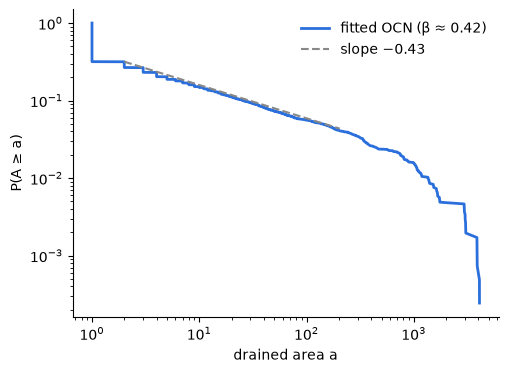

In [6]:
a, pa = area_exceedance(grids["drained_area"])
mask = (a >= 2) & (a <= 0.05 * a.max())
beta = -np.polyfit(np.log(a[mask]), np.log(pa[mask]), 1)[0]

fig, ax = plt.subplots(figsize=(5.5, 4))
ax.loglog(a, pa, lw=2, color="#2a6fdb", label=f"fitted OCN (β ≈ {beta:.2f})")
ax.loglog(a[mask], pa[mask][0] * (a[mask] / a[mask][0]) ** -0.43, "--", color="#888", label="slope −0.43")
ax.set_xlabel("drained area a"); ax.set_ylabel("P(A ≥ a)")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)

## 3. How slow is it?

Each annealing iteration resets a visited flag on **every** cell before it checks for cycles
(see `ocn_single_erosion_event` in PyOCN's `c_src/ocn.c`). So one iteration costs $O(N)$ for $N$
cells. The default schedule runs $O(N)$ iterations. Expect roughly $O(N^2)$ total.

Set `INCLUDE_256 = True` to add a 256x256 run. Expect about a minute per seed.

In [7]:
INCLUDE_256 = False
sizes = [16, 32, 64, 128] + ([256] if INCLUDE_256 else [])
records = time_fit(sizes, seeds=[0, 1, 2])

by_size = {s: [r for r in records if r["size"] == s] for s in sizes}
print(f"{'size':>6} {'cells':>7} {'iters':>9} {'fit s':>8} {'export s':>9}")
for s, rs in by_size.items():
    print(f"{s:>6} {s*s:>7} {rs[0]['iterations']:>9} "
          f"{np.mean([r['fit_s'] for r in rs]):>8.3f} {np.mean([r['export_s'] for r in rs]):>9.3f}")

cells = np.array([s * s for s in sizes])
fit_s = np.array([np.mean([r["fit_s"] for r in by_size[s]]) for s in sizes])
exponent = np.polyfit(np.log(cells[1:]), np.log(fit_s[1:]), 1)[0]
print(f"\nfit time ~ cells^{exponent:.2f}")

  size   cells     iters    fit s  export s
    16     256     10304    0.006     0.001
    32    1024     41217    0.050     0.005
    64    4096    164868    0.501     0.017
   128   16384    659472    5.640     0.084

fit time ~ cells^1.71


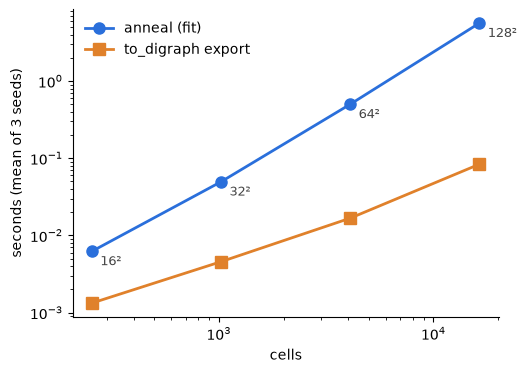

In [8]:
fig, ax = plt.subplots(figsize=(5.5, 4))
ax.loglog(cells, fit_s, "o-", lw=2, ms=8, color="#2a6fdb", label="anneal (fit)")
ax.loglog(cells, [np.mean([r["export_s"] for r in by_size[s]]) for s in sizes],
          "s-", lw=2, ms=8, color="#e0812b", label="to_digraph export")
for c, t, s in zip(cells, fit_s, sizes):
    ax.annotate(f"{s}²", (c, t), textcoords="offset points", xytext=(6, -10), fontsize=9, color="#444")
ax.set_xlabel("cells"); ax.set_ylabel("seconds (mean of 3 seeds)")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)

## 4. Chunked rivers without fitting the whole world

The goal: generate terrain chunk by chunk, with rivers that make sense across chunk borders, and
without annealing the full world first. A full-world fit is $O(N^2)$, and an endless world
cannot be fitted at all.

`ChunkedWorld` is a two-level sketch:

1. **Coarse level.** Fit a small OCN with one cell per chunk. This says which neighbor each chunk
   drains into, and how many chunks drain through it. It is the only global step, and it is cheap
   (a 16x16 coarse grid fits in milliseconds).
2. **Shared border points.** Where chunk A drains into chunk B, the crossing cell is hashed from
   the world seed and the pair (A, B). Both chunks compute the same cell without talking to each
   other.
3. **Local level.** Each chunk anneals its own OCN with one outlet at that border cell. Its seed is
   hashed from the world seed and its coordinates.
4. **Inflow.** Water from upstream chunks enters at the inlet cells. Its amount is
   (coarse drained area × cells per chunk). It is added along the local path to the outlet.

PyOCN cannot weight a cell with external inflow during annealing. So the local trunk path is
shaped as if it were a headwater, and the inflow is added afterward. That is the main approximation.

mean local fit per 32x32 chunk: 0.066s


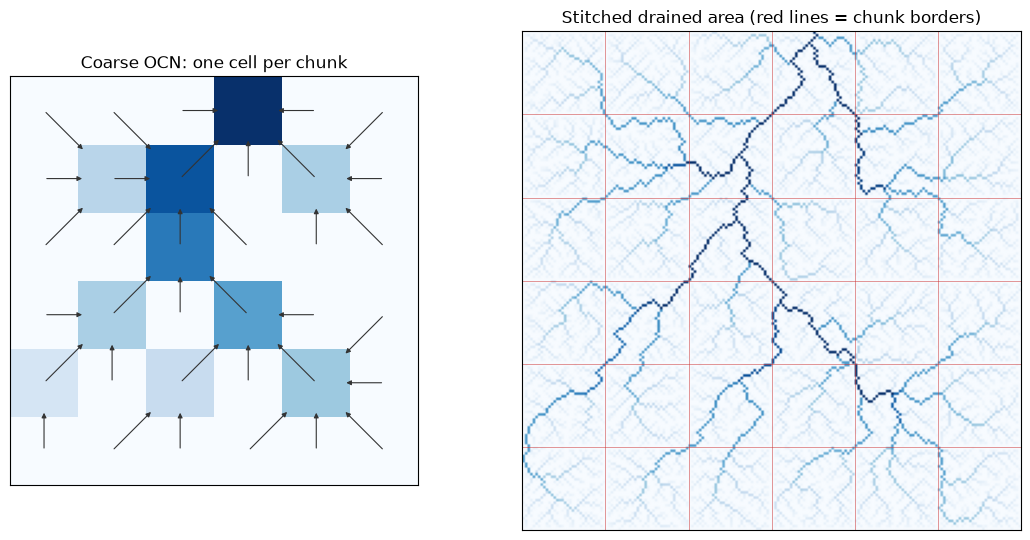

In [9]:
world = ChunkedWorld(world_seed=7, world_chunks=6, chunk_size=32)

# Generate chunks in a shuffled order to show that order does not matter.
order = [(r, c) for r in range(world.world_chunks) for c in range(world.world_chunks)]
np.random.default_rng(0).shuffle(order)
chunks = {rc: world.chunk(*rc) for rc in order}
area, stitched = world.assemble(chunks)
print(f"mean local fit per {world.chunk_size}x{world.chunk_size} chunk: "
      f"{np.mean([c.fit_seconds for c in chunks.values()]):.3f}s")

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), gridspec_kw={"width_ratios": [1, 2]})
axes[0].imshow(world.coarse_area, cmap="Blues", norm=mpl.colors.PowerNorm(0.5))
draw_flow(axes[0], world.coarse_directions, length=0.6)
axes[0].set_title("Coarse OCN: one cell per chunk")

axes[1].imshow(area, cmap="Blues", norm=AREA_NORM)
for k in range(1, world.world_chunks):
    axes[1].axhline(k * world.chunk_size - 0.5, color="#c33", lw=0.6, alpha=0.6)
    axes[1].axvline(k * world.chunk_size - 0.5, color="#c33", lw=0.6, alpha=0.6)
axes[1].set_title("Stitched drained area (red lines = chunk borders)")
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()

### Do the chunks agree?

Four checks on the stitched world:

- It is one DAG with exactly one outlet.
- Drained area recomputed from scratch on the stitched graph equals the per-chunk areas. This means
  the inflow amounts are exactly right.
- PyOCN itself accepts the stitched graph as a valid OCN (no crossing edges, all 8-neighbor moves).
- A chunk regenerated in a fresh world object is identical.

In [10]:
outlets = [n for n in stitched if stitched.out_degree(n) == 0]
recount = {}
for n in nx.topological_sort(stitched):
    recount[n] = 1 + sum(recount[p] for p in stitched.predecessors(n))
area_error = max(abs(recount[n] - stitched.nodes[n]["area"]) for n in stitched)

for n in stitched:
    stitched.nodes[n]["pos"] = n
stitched_ocn = po.OCN.from_digraph(stitched)  # raises if the graph is not a valid OCN

fresh = ChunkedWorld(world_seed=7, world_chunks=6, chunk_size=32).chunk(2, 3)
print("acyclic:", nx.is_directed_acyclic_graph(stitched), "| outlets:", len(outlets))
print("max drained-area error:", area_error)
print("PyOCN accepts stitched graph, energy:", round(stitched_ocn.energy, 1))
print("chunk (2, 3) reproducible:", np.array_equal(fresh.area, chunks[(2, 3)].area))

acyclic: True | outlets: 1
max drained-area error: 0.0
PyOCN accepts stitched graph, energy: 133235.9
chunk (2, 3) reproducible: True


### How good are the stitched rivers?

Compare the stitched world with one global fit of the same size. The global fit is the reference.
Lower energy means more river-like. The exceedance curves show whether the scaling law survives
stitching.

                                  energy   seconds
global initial V network          240162          
global fit                        137002     23.73
stitched chunks (all)             133236      2.38
one chunk                                    0.066


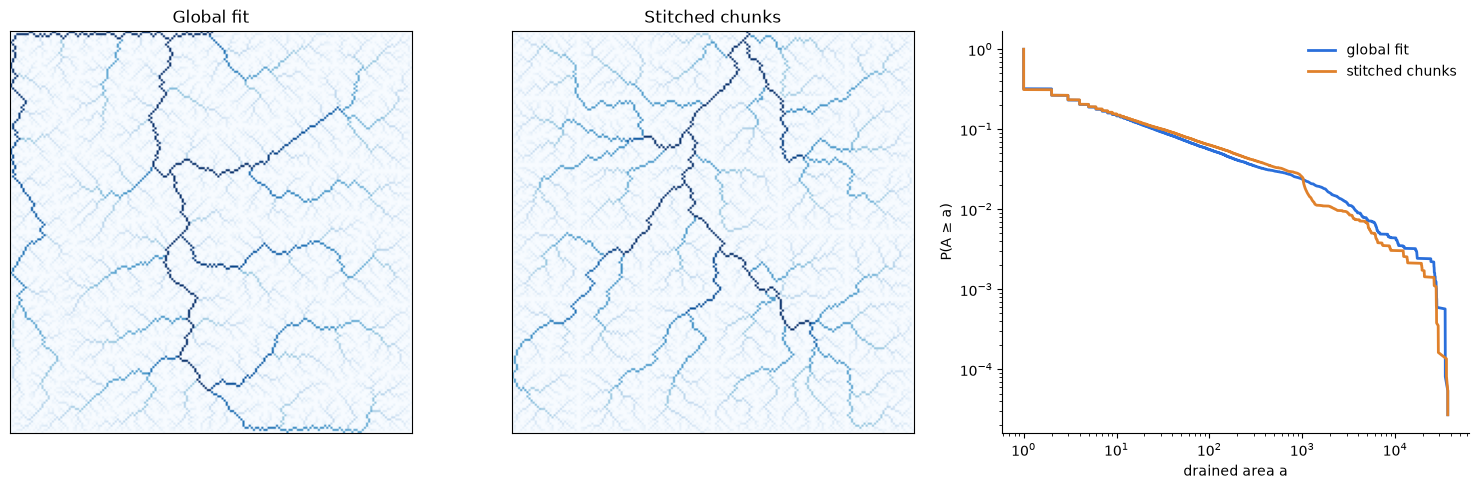

In [11]:
side = world.world_chunks * world.chunk_size
start = time.perf_counter()
global_ocn = po.OCN.from_net_type("V", dims=(side, side), random_state=7)
initial_energy = global_ocn.energy
global_ocn.fit()
global_seconds = time.perf_counter() - start
chunk_seconds = sum(c.fit_seconds for c in chunks.values())

print(f"{'':<28}{'energy':>12}{'seconds':>10}")
print(f"{'global initial V network':<28}{initial_energy:>12.0f}{'':>10}")
print(f"{'global fit':<28}{global_ocn.energy:>12.0f}{global_seconds:>10.2f}")
print(f"{'stitched chunks (all)':<28}{stitched_ocn.energy:>12.0f}{chunk_seconds:>10.2f}")
print(f"{'one chunk':<28}{'':>12}{chunk_seconds / len(chunks):>10.3f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), gridspec_kw={"width_ratios": [1, 1, 1.1]})
axes[0].imshow(rasters(global_ocn)["drained_area"], cmap="Blues", norm=AREA_NORM)
axes[0].set_title("Global fit")
axes[1].imshow(area, cmap="Blues", norm=AREA_NORM)
axes[1].set_title("Stitched chunks")
for ax in axes[:2]:
    ax.set_xticks([]); ax.set_yticks([])
for name, grid, color in [("global fit", rasters(global_ocn)["drained_area"], "#2a6fdb"),
                          ("stitched chunks", area, "#e0812b")]:
    a, pa = area_exceedance(grid)
    axes[2].loglog(a, pa, lw=2, color=color, label=name)
axes[2].set_xlabel("drained area a"); axes[2].set_ylabel("P(A ≥ a)")
axes[2].legend(frameon=False)
axes[2].spines[["top", "right"]].set_visible(False)
plt.tight_layout()

For this seed and size, the stitched world reaches slightly lower energy than the global fit, in
about a tenth of the time. That result needs care before reading much into it. It is one seed. The
outlets differ (the global fit uses the V network's fixed outlet). And PyOCN's default schedule may
be under-annealed at 192x192. It does show that stitching does not obviously cost river quality at
this scale. Notice the kink in the stitched curve near  = 1024$, which is one chunk's area. That
kink is where the chunk structure shows.

## 5. Is this a good fit for the seeded PA VAE?

What lines up:

- **Same interface shape.** `parent(seed, cell) -> direction` is the PA query interface with
  grid cells as queries. The answer has only 8 options, and usually fewer are valid.
- **Random access is the point.** The chunk prototype already needs "answer for this region, from
  the seed alone". A learned model would make that a direct query.
- **There is a real speed reason.** Annealing is roughly $O(N^2)$ per world. A trained decoder is
  $O(1)$ per query, if it can keep the structure.
- **Cheap metrics exist.** Acyclicity, a single outlet, no crossings, the $\beta \approx 0.43$
  exceedance slope, and energy compared with annealed OCNs.

What is harder than the PA case:

- **Validity is global and strict.** One wrong arrow can make a cycle or a crossing, which breaks
  the tree. In the PA tree, any older parent is valid. Here a learned decoder needs a repair or
  projection step, or it needs to decode something that is valid by construction.
- **Drained area is a global function of all arrows.** Every downstream query depends on everything
  upstream. This is the long-range dependency that a bounded latent may struggle to keep.
- **Space replaces arrival order.** PA has a natural query order. A grid has no order, so the
  conditioning has to be spatial (coordinates, neighborhoods, or a hierarchy).

A possible split, given the prototype: keep the coarse level and the hashed border points as they
are, since they are cheap and exactly consistent. Use a learned model only to replace the local
annealing inside a chunk, conditioned on the chunk seed, its outlet, and its inlets with their
inflow. That turns the $O(\text{chunk}^2)$ fit into one decoder pass. It also keeps the global
constraints in code that is correct by construction.

Open issues with the prototype itself:

- The coarse OCN is still a global fit. An endless world needs a coarse level that is itself
  generated lazily, for example a third, coarser level of the same scheme.
- Local trunks are shaped without knowing about their inflow, so large rivers wander like small
  streams inside a chunk.
- Elevation is not stitched yet. Each chunk's PyOCN elevation is relative to its own outlet.